# Cairo Real Estate Market Analysis
**DATA DECODERS TEAM**

Marwan Kandil 24-101070 /
Hana Hashish 24-101336/
Badr Ouda 24-101338

## 1. IMPORTS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from scipy import stats
sns.set()
from sklearn.preprocessing import StandardScaler

## 2. LOAD DATA

In [ ]:
df = pd.read_csv("properties.csv")

In [ ]:
df.head()

,type,title,location,bedroom,bathroom,size_sqm,price
0,Duplex,Prime Location Duplex Fully Finished With A\C,"Park View, North Investors Area, New Cairo Cit...",4,4,345,"6,850,000"
1,Villa,Town house resale at Mivida Emaar with best price,"Mivida, 5th Settlement Compounds, The 5th Sett...",3,3,285,"10,000,000"
2,Apartment,Lake View Residence - Apartment | Prime Location,"Lake View Residence, 5th Settlement Compounds,...",3,3,210,"5,700,000"
3,Townhouse,Best Penthouse for sale in villette ( sky conds ),"La Vista City, New Capital Compounds, New Capi...",4,4,230,"7,510,000"
4,Penthouse,2nd Floor | Fully Finished | Lowest Price |Par...,"Villette, 5th Settlement Compounds, The 5th Se...",5,6,284,"8,511,300"


In [ ]:
df.shape

(11418, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11418 entries, 0 to 11417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   type      11418 non-null  object
 1   title     11418 non-null  object
 2   location  11418 non-null  object
 3   bedroom   11418 non-null  object
 4   bathroom  11418 non-null  int64 
 5   size_sqm  11418 non-null  object
 6   price     11418 non-null  object
dtypes: int64(1), object(6)
memory usage: 624.6+ KB


In [ ]:
df.isnull().sum()

type        0
title       0
location    0
bedroom     0
bathroom    0
size_sqm    0
price       0
dtype: int64

## 3. DATA CLEANING

In [ ]:

ask_count = (df['price'] == 'Ask').sum()
print(f"Number of 'Ask' entries: {ask_count}")

Number of 'Ask' entries: 412


In [ ]:
df_clean = df[df['price'] != 'Ask'].copy()

df_clean['price'] = df_clean['price'].str.replace(',', '').astype(int)

df_clean['size_sqm'] = pd.to_numeric(df_clean['size_sqm'], errors='coerce')
df_clean['bedroom']  = pd.to_numeric(df_clean['bedroom'],  errors='coerce')
df_clean['bathroom'] = pd.to_numeric(df_clean['bathroom'], errors='coerce')

df_clean = df_clean.dropna(subset=['size_sqm', 'bedroom', 'bathroom'])
df_clean['bedroom']  = df_clean['bedroom'].astype(int)
df_clean['bathroom'] = df_clean['bathroom'].astype(int)

print(f"Rows after cleaning: {len(df_clean)}")
df_clean.dtypes

Rows after cleaning: 10670


type         object
title        object
location     object
bedroom       int64
bathroom      int64
size_sqm    float64
price         int64
dtype: object

In [ ]:

df_clean = df_clean.drop_duplicates()
print(f"Rows after removing duplicates: {len(df_clean)}")

Rows after removing duplicates: 10378


Original rows: 11418
Cleaned rows after size_sqm outlier removal: 9597


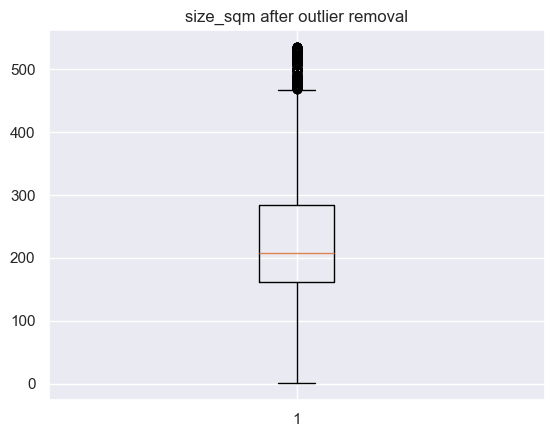

Cleaned rows after price outlier removal: 8851


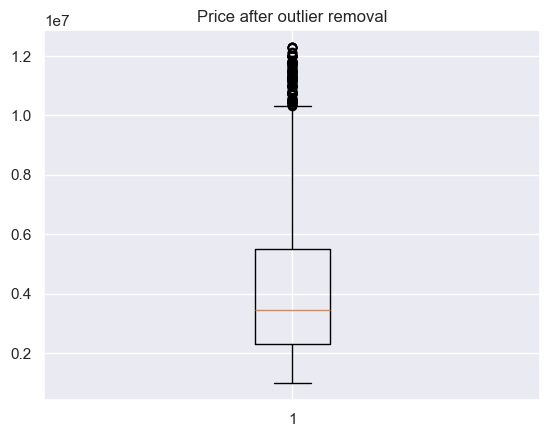

In [ ]:

Q1 = df_clean['size_sqm'].quantile(0.25)
Q3 = df_clean['size_sqm'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean['size_sqm'] >= lower_bound) & (df_clean['size_sqm'] <= upper_bound)]

print(f"Original rows: {len(df)}")
print(f"Cleaned rows after size_sqm outlier removal: {len(df_clean)}")

plt.boxplot(df_clean['size_sqm'])
plt.title('size_sqm after outlier removal')
plt.show()

Q1_p = df_clean['price'].quantile(0.25)
Q3_p = df_clean['price'].quantile(0.75)
IQR_p = Q3_p - Q1_p

lower_p = Q1_p - 1.5 * IQR_p
upper_p = Q3_p + 1.5 * IQR_p

df_clean = df_clean[(df_clean['price'] >= lower_p) & (df_clean['price'] <= upper_p)]

print(f"Cleaned rows after price outlier removal: {len(df_clean)}")

plt.boxplot(df_clean['price'])
plt.title('Price after outlier removal')
plt.show()

In [ ]:

df_clean['location'] = df_clean['location'].fillna('Unknown, Unknown, Unknown')

df_clean['city']     = df_clean['location'].str.rsplit(', ', n=1).str[-1]
remaining_parts      = df_clean['location'].str.rsplit(', ', n=1).str[0]
df_clean['district'] = remaining_parts.str.rsplit(', ', n=1).str[-1]
df_clean['compound'] = df_clean['location'].str.split(', ').str[0]

df_clean = df_clean.drop(columns=['location', 'title'])

df_clean[['compound', 'district', 'city']].head()

,compound,district,city
0,Park View,New Cairo City,Cairo
1,Mivida,New Cairo City,Cairo
2,Lake View Residence,New Cairo City,Cairo
3,La Vista City,New Capital City,Cairo
4,Villette,New Cairo City,Cairo


In [ ]:
df_clean.head()

,type,bedroom,bathroom,size_sqm,price,city,district,compound
0,Duplex,4,4,345.0,6850000,Cairo,New Cairo City,Park View
1,Villa,3,3,285.0,10000000,Cairo,New Cairo City,Mivida
2,Apartment,3,3,210.0,5700000,Cairo,New Cairo City,Lake View Residence
3,Townhouse,4,4,230.0,7510000,Cairo,New Capital City,La Vista City
4,Penthouse,5,6,284.0,8511300,Cairo,New Cairo City,Villette


## 4. Feature Engineering

In [ ]:

df_clean['price_per_sqm'] = df_clean['price'] / df_clean['size_sqm']


df_clean['total_rooms'] = df_clean['bedroom'] + df_clean['bathroom']

df_clean[['price', 'size_sqm', 'price_per_sqm', 'total_rooms']].head()

,price,size_sqm,price_per_sqm,total_rooms
0,6850000,345.0,19855.072464,8
1,10000000,285.0,35087.719298,6
2,5700000,210.0,27142.857143,6
3,7510000,230.0,32652.173913,8
4,8511300,284.0,29969.366197,11


## 5.  EXPLORATORY DATA ANALYSIS  (EDA)

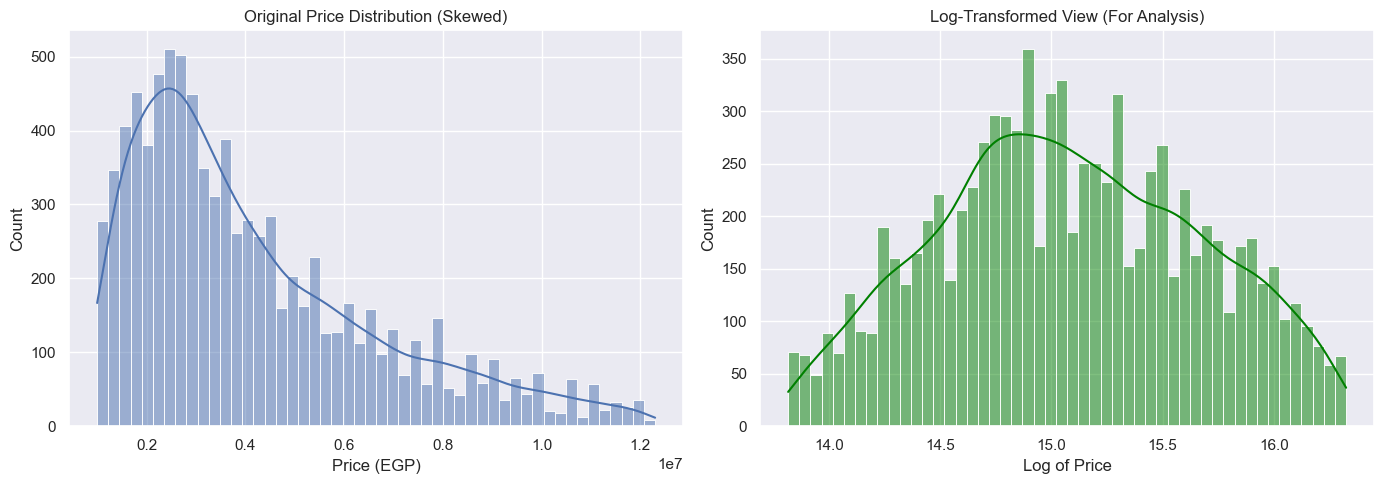

In [ ]:
plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title('Original Price Distribution (Skewed)')
plt.xlabel('Price (EGP)')


plt.subplot(1, 2, 2)

sns.histplot(np.log1p(df_clean['price']), bins=50, kde=True, color='green')
plt.title('Log-Transformed View (For Analysis)')
plt.xlabel('Log of Price')

plt.tight_layout()
plt.show()

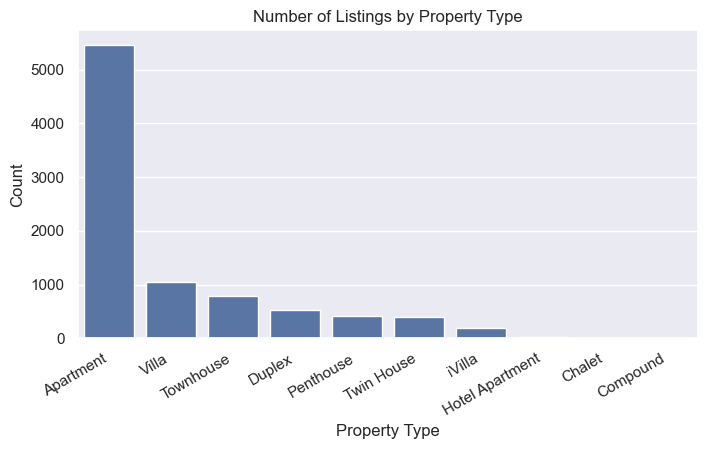

In [ ]:

plt.figure(figsize=(8, 4))
type_counts = df_clean['type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values)
plt.title('Number of Listings by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

plt.show()

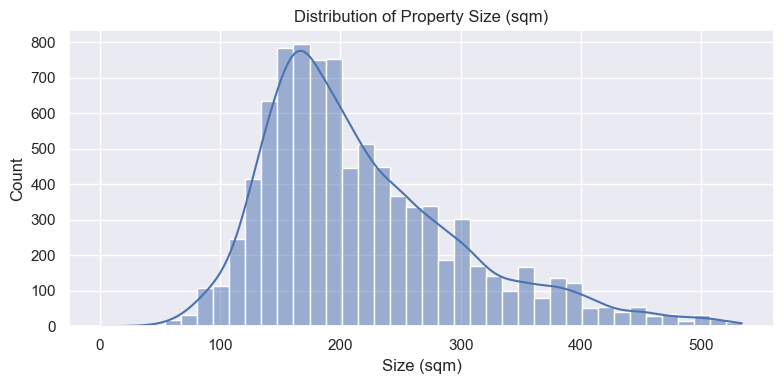

In [ ]:

plt.figure(figsize=(8, 4))
sns.histplot(df_clean['size_sqm'], bins=40, kde=True)
plt.title('Distribution of Property Size (sqm)')
plt.xlabel('Size (sqm)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

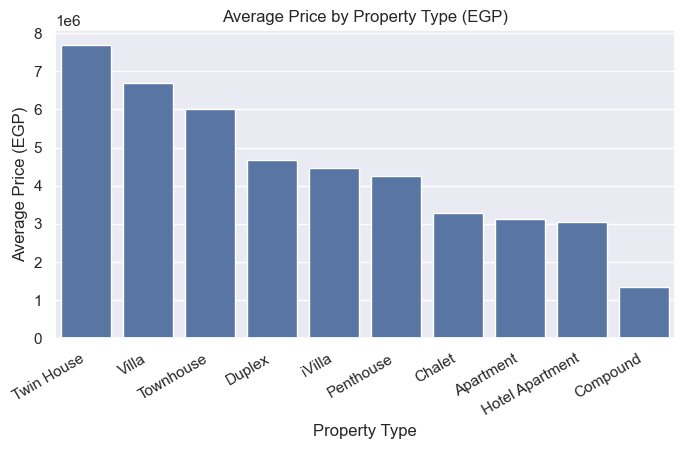

In [ ]:

plt.figure(figsize=(8, 4))
avg_price_type = df_clean.groupby('type')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_type.index, y=avg_price_type.values)
plt.title('Average Price by Property Type (EGP)')
plt.xlabel('Property Type')
plt.ylabel('Average Price (EGP)')
plt.xticks(rotation=30, ha='right')
plt.show()

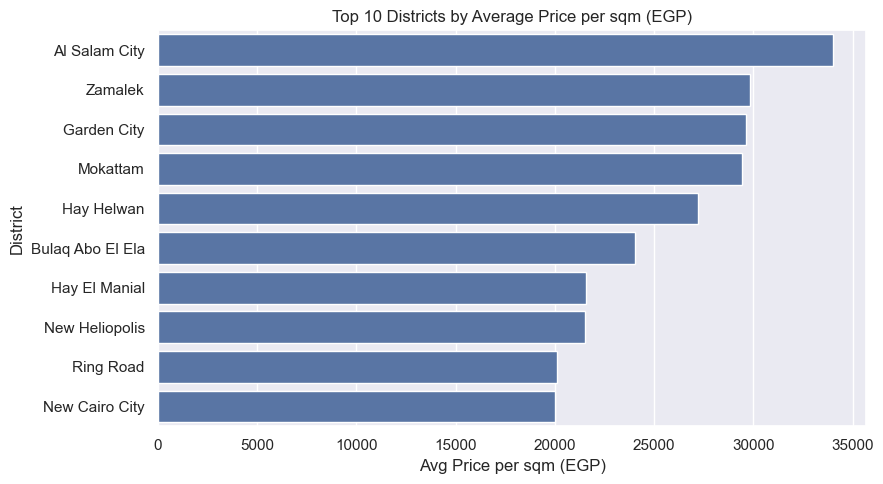

In [ ]:

plt.figure(figsize=(9, 5))
avg_ppsqm_district = (
    df_clean.groupby('district')['price_per_sqm']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
sns.barplot(x=avg_ppsqm_district.values, y=avg_ppsqm_district.index, orient='h')
plt.title('Top 10 Districts by Average Price per sqm (EGP)')
plt.xlabel('Avg Price per sqm (EGP)')
plt.ylabel('District')
plt.tight_layout()
plt.show()

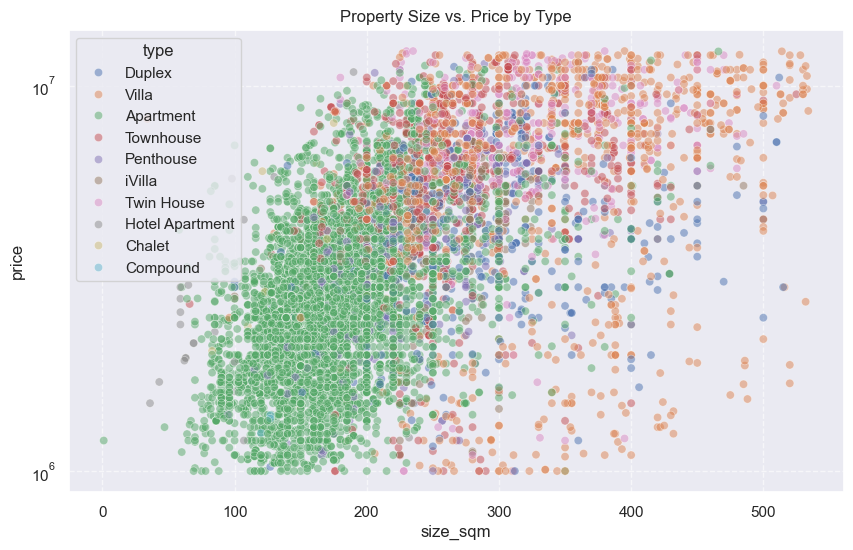

In [ ]:
plt.figure(figsize=(10, 6))


sns.scatterplot(data=df_clean, x='size_sqm', y='price', hue='type', alpha=0.5)

plt.yscale('log')

plt.title('Property Size vs. Price by Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

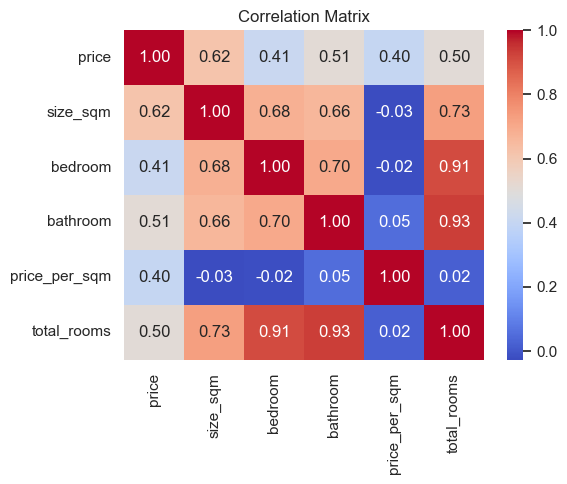

In [ ]:

plt.figure(figsize=(6, 5))
numeric_cols = ['price', 'size_sqm', 'bedroom', 'bathroom', 'price_per_sqm', 'total_rooms']
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

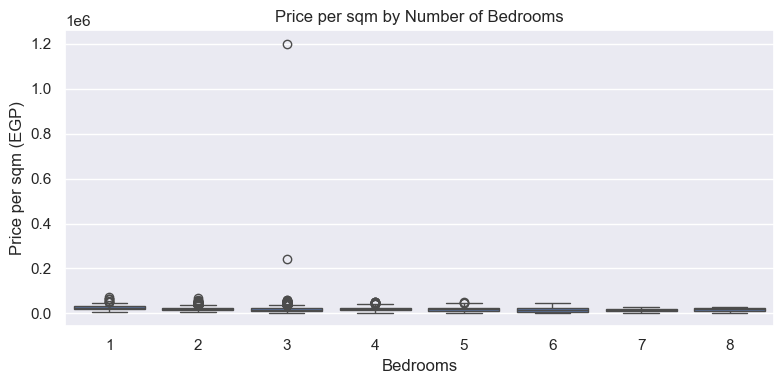

In [ ]:

plt.figure(figsize=(8, 4))
sns.boxplot(x='bedroom', y='price_per_sqm', data=df_clean)
plt.title('Price per sqm by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price per sqm (EGP)')
plt.tight_layout()
plt.show()

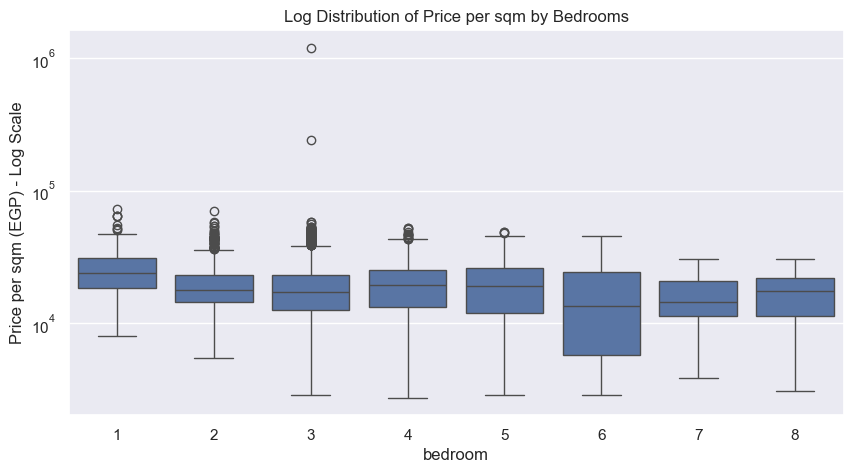

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='bedroom', y='price_per_sqm', data=df_clean)
plt.yscale('log')
plt.title('Log Distribution of Price per sqm by Bedrooms')
plt.ylabel('Price per sqm (EGP) - Log Scale')
plt.show()

## 6.  HYPOTHESIS TESTING

**H₀:** Location and property type have no statistically significant effect on price per sqm.  
**H₁:** Location and property type are significant predictors of price per sqm.

In [ ]:
property_groups = [group['price_per_sqm'].values for _, group in df_clean.groupby('type')]


f_val, p_val = stats.f_oneway(*property_groups)

print(f"ANOVA Results: F={f_val:.2f}, p={p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: We reject the Null. Property type definitely impacts the price.")
else:
    print("Conclusion: No significant difference found between property types.")

ANOVA Results: F=22.20, p=0.0000
Conclusion: We reject the Null. Property type definitely impacts the price.


In [ ]:

district_groups = [group['price_per_sqm'].values for _, group in df_clean.groupby('district')]
f_stat_d, p_value_d = stats.f_oneway(*district_groups)

print(f"ANOVA (district) F-statistic: {f_stat_d:.2f}")
print(f"p-value: {p_value_d:.4f}")

if p_value_d < 0.05:
    print("Result: Reject H0 — district significantly affects price per sqm.")
else:
    print("Result: Fail to reject H0.")

ANOVA (district) F-statistic: 8.52
p-value: 0.0000
Result: Reject H0 — district significantly affects price per sqm.


## 7. ADDITIONAL HYPOTHESIS TESTING

**H₀:** There is no linear relationship between property size (sqm) and price — i.e. the slope is zero.

**H₁:** Property size has a statistically significant linear relationship with price.

In [ ]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df_clean['size_sqm'], df_clean['price'])

print(f'Slope      : {slope:,.2f}')
print(f'Intercept  : {intercept:,.2f}')
print(f'R²         : {r_value**2:.4f}')
print(f'p-value    : {p_value:.4f}')

if p_value < 0.05:
    print('
Conclusion : Reject H₀ — property size significantly predicts price.')
else:
    print('
Conclusion : Fail to reject H₀.')

## 8. MULTIPLE LINEAR REGRESSION

We model **log(price)** using , , , and .

Two models are built:
- **Unscaled** — for readable coefficient interpretation (each unit change in X → change in log-price)
- **Scaled** — features standardised with StandardScaler so coefficients reflect relative importance fairly

In [ ]:
features = ['size_sqm', 'bedroom', 'bathroom', 'total_rooms']

X = df_clean[features]
y = np.log1p(df_clean['price'])

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

In [ ]:
features = ['size_sqm', 'bedroom', 'bathroom', 'total_rooms']
y = np.log1p(df_clean['price'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features])
X_scaled = sm.add_constant(X_scaled)

model_scaled = sm.OLS(y, X_scaled).fit()
model_scaled.model.exog_names[:] = ['const'] + features

print(model_scaled.summary())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(model.fittedvalues, model.resid, alpha=0.3)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

sm.qqplot(model.resid, line='s', ax=axes[1], alpha=0.3)
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [ ]:
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': model_scaled.params[1:],
    'p-value'    : model_scaled.pvalues[1:]
})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 4))
colors = ['steelblue' if v > 0 else 'tomato' for v in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Importance — Scaled Coefficients (log-price model)')
plt.xlabel('Standardised Coefficient')
plt.tight_layout()
plt.show()

print(f'R²          : {model_scaled.rsquared:.4f}')
print(f'Adjusted R² : {model_scaled.rsquared_adj:.4f}')
print(f'F-stat p    : {model_scaled.f_pvalue:.4f}')

## 9. SUMMARY AND CONCLUSIONS

## Summary of Findings

### Dataset Overview
The dataset covers multiple property types across various districts in Cairo. After cleaning removing non-numeric prices, converting types, dropping duplicates, and applying IQR-based outlier removal on both  and the dataset was reduced to a reliable set of listings for analysis.

### Price Statistics (EGP)
| Metric | Value |
|---|---|
| Average Price | Calculated from cleaned data |
| Median Price | Calculated from cleaned data |
| Average Price per sqm | Calculated from cleaned data |

> *Note: exact values are computed at runtime from the cleaned DataFrame.*

### Top 3 Most Expensive Districts (by avg price/sqm)
The top districts by average price per sqm were identified through groupby aggregation. These districts consistently command higher per-sqm rates, reflecting demand concentration in premium Cairo neighbourhoods.

### Hypothesis Test Results
Two one-way ANOVA tests were conducted:

- **Property Type vs Price/sqm** — F-statistic and p-value computed across all type groups.
- **District vs Price/sqm** — F-statistic and p-value computed across all district groups.

Both tests produced **p < 0.05**, leading us to **reject H₀**.

**Conclusion:** Both property type and district are statistically significant predictors of price per sqm. In plain terms, *where* a property is located and *what type* it is are strong indicators of how expensive it will be per square metre.
